<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Antibody Engineering

Comprehensive antibody engineering workflow using BioLM.ai models.

Antibodies are highly specific proteins with incredible binding prowess, important immune mediated interactions and high therapuetic potential. Benefiting from recent machine learning success in biology, and specifically protein design , computational antibody engineering has become extremely accesible. In the following guides, motivated by the binder design challenges proposed with the BenchBB dataset and the expediency of the BioLM SDK and API, several ml methods for antibody engineering are demonstrated.

---
## Previously

Using a structure and antigen conditioned candidate proposal method, 100 variants were generated for four of the proposed BenchBB targets ('IL7Ra', 'PDL-1', 'EGFR' and MBP) containing solved structures of antibodies in complex with the target deposited in the pdb. Then the varaints were scored using sequence based PLM's for a proxy on desired intrinsic poperties. Finally, structure prediction methods were used to examine the self consistency of variants and quality of potential binders. 

---

For specific property prediction including binding prediction, specific models can be developed. The data to train these models can be mined from publicly available databases or aquired through earlier rounds of binder design and experimental validation. Importantly, as opposed to the previously examined methods, labels for the data are required.

Extracting relevant numeric features for training this predictors is important and embeddings from PLMs are a popular choice. Below Embeddings are extracted for the varaints.


## Import Required Libraries

In [1]:
from IPython.display import JSON
import requests
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pathlib import Path
from sklearn.decomposition import PCA
from Bio import PDB
from Bio.PDB import *

from biolmai import BioLM
from helpers.styling import apply_plot_styling
apply_plot_styling()

In [2]:
samples_df = pd.read_csv("data/protein/benchbb_antibody_targets/variant_candidates.csv")

Downstream Analysis and Exploration of Candidates

Generate IgT5 embeddings and visualize the results  with PCA

In [3]:
# Get IgT5 embeddings
def batch_and_embed_igt5(
    df,
    heavy_col='heavy',
    light_col='light',
):
    """
    Sends heavy/light chain pairs in batches to an API, and collects embeddings from response.

    Assumes:
        - Response includes:
            - results: list of dicts
                - each has 'embeddings' key with a list of floats
    Returns:
        List of dicts: {'heavy': str, 'light': str, 'embedding': list[float]}
    """
    results = []
    heavy_list = df[heavy_col].tolist()
    light_list = df[light_col].tolist()

    data = [{"heavy": h, "light": l} for h, l in zip(heavy_list, light_list)]

    start = time.time()
    result = BioLM(entity="igt5-paired", action="encode", items=data)
    end = time.time()
    
    print(f"IgT5 Encoding took {end - start:.4f} seconds.")

    for (h, l), item in zip(zip(heavy_list, light_list), result):
        results.append({
            "heavy": h,
            "light": l,
            "embedding": item["embeddings"]
        })

    return results


In [4]:
igt5_embeddings = batch_and_embed_igt5(samples_df)

IgT5 Encoding took 64.0947 seconds.


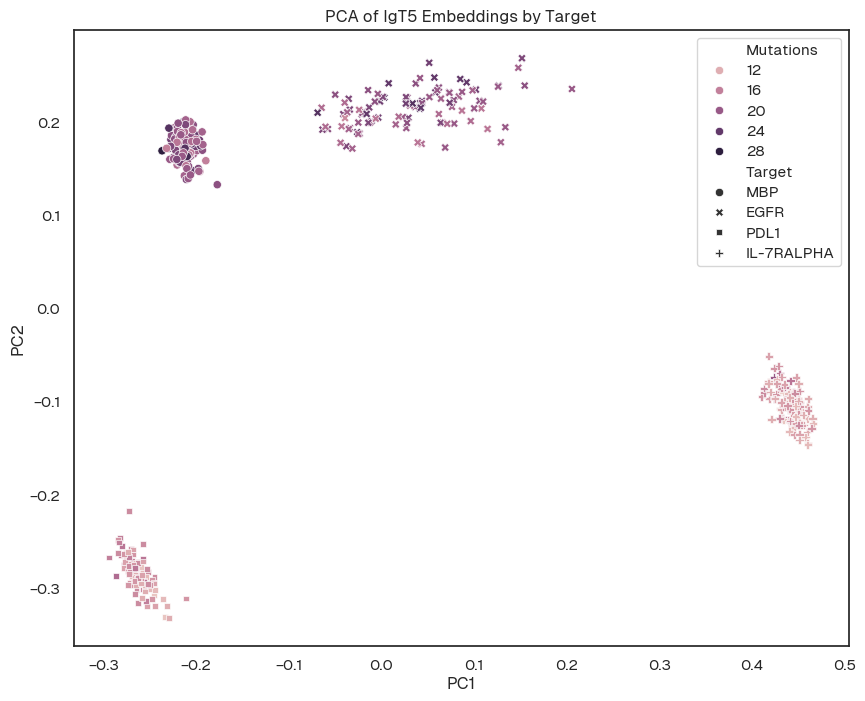

In [5]:
# Combine embeddings and perform PCA
all_embeddings = []
for item in igt5_embeddings:
    all_embeddings.append(item["embedding"])

# Convert to numpy array
X = np.array(all_embeddings)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Target': samples_df["target"],
    'Mutations': samples_df["mutations"]
})

# Plot
plt.figure(figsize=(10, 8))
s = sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Mutations", style="Target")

plt.title('PCA of IgT5 Embeddings by Target')
plt.show()

We can see that there is clear separation as projected with PCA among the variants with respect to the targets. There is also  some spread along the first two principal components for variants within each cluster although less so for the MBP target cluster. To aid in interpretation of what properties the latent space of the model is actually extracting, physio-chemical and QSAR descriptors can be correlated with the embeddings principal components. These features can also be used to train property predictive models.

In [6]:
def batch_and_encode_peptides(
    df,
    sequence_col='sequence',
):
    """
    Sends sequences in batches to an API, and collects embeddings from response.

    Assumes:
        - Response includes:
            - results: list of dicts
                - each has 'features' key with a list of floats
    Returns:
        List of dicts: {'sequence': str, 'features': dict[str:float]}
    """
    results = []
    sequences = df[sequence_col].tolist()

    data = [{"sequence": seq} for seq in sequences]

    start = time.time()
    result = BioLM(entity="peptides", action="encode", items=data)
    end = time.time()
    
    print(f"Peptides Encoding took {end - start:.4f} seconds.")

    for seq, item in zip(sequences, result):
        results.append({
            "sequence": seq, **item["features"]
        })

    return results

In [7]:
peptides_results_heavy = batch_and_encode_peptides(samples_df, sequence_col="heavy")
peptides_results_light = batch_and_encode_peptides(samples_df, sequence_col="light")

Peptides Encoding took 29.6991 seconds.
Peptides Encoding took 25.0100 seconds.


In [8]:
peptides_results_heavy = pd.DataFrame(peptides_results_heavy).add_prefix("heavy_")
peptides_results_light = pd.DataFrame(peptides_results_light).add_prefix("light_")

In [9]:
pca = PCA(n_components=10)
pca_components = pca.fit_transform(X)

In [14]:
drop_list = ['heavy', 'light', 'global_score', 'score', 'mutations', 'seq_recovery', 'heavy_cdr1', 'heavy_cdr2', 'heavy_cdr3', 'light_cdr1',
       'light_cdr2', 'light_cdr3', 'light_sequence','heavy_sequence']
correlation_df = pd.concat([samples_df, peptides_results_heavy, peptides_results_light, pd.DataFrame(pca_components, columns = [f"PC{i}" for i in range(10)])], axis=1)
correlation_df.drop(drop_list, inplace=True, axis=1)

In [15]:
features = correlation_df.drop(["target"], axis=1).iloc[:, :-10]
targets = correlation_df.drop(["target"], axis=1).iloc[:, -10:]

# Compute correlation between each feature and each target
correlations = pd.DataFrame({
    target: features.corrwith(targets[target])
    for target in targets.columns
})

# Get top N correlated features per target
top_n = 5  # adjust as needed
results = []

for target in correlations.columns:
    # Drop NaNs and sort by absolute correlation
    series = correlations[target].dropna()
    top_features = series.reindex(series.abs().sort_values(ascending=False).index).head(top_n)
    
    for feature, corr in top_features.items():
        results.append({
            'IgT5 Principal Component': target,
            'Feature': feature,
            'Correlation': corr
        })

# Convert results to a long-form DataFrame
top_correlations_long = pd.DataFrame(results)

# Optional: Sort final output by target and strength of correlation
top_correlations_long = top_correlations_long.sort_values(
    by=["IgT5 Principal Component", "Correlation"], key=lambda col: col.abs() if col.name == "Correlation" else col
)


/home/c/anaconda3/envs/biolm/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/c/anaconda3/envs/biolm/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


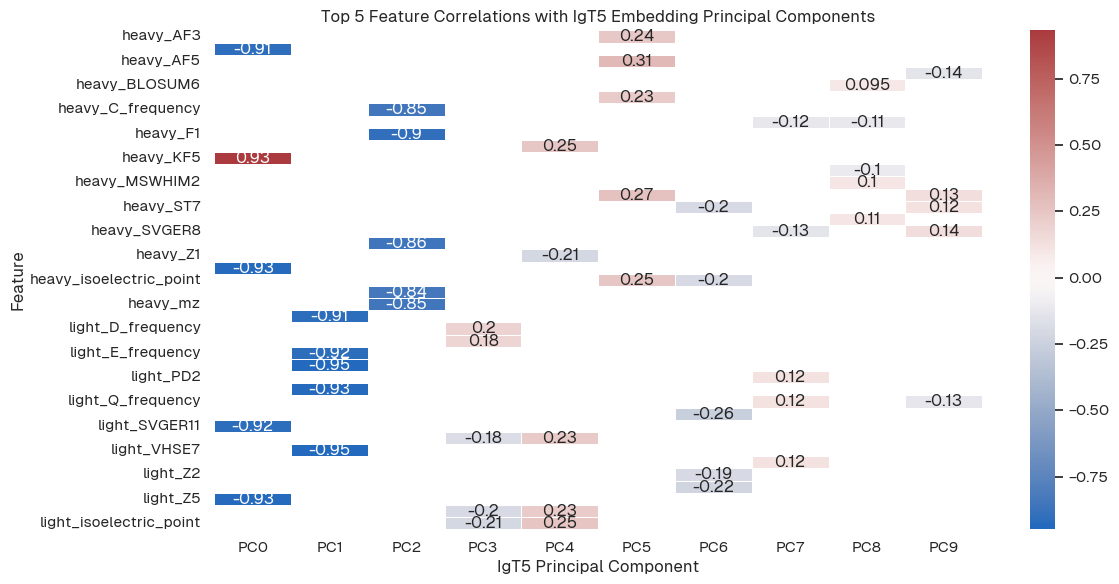

In [16]:
heatmap_data = top_correlations_long.pivot(index="Feature", columns="IgT5 Principal Component", values="Correlation")

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, center=0, cmap="vlag", linewidths=0.5)
plt.title("Top 5 Feature Correlations with IgT5 Embedding Principal Components")
plt.tight_layout()
plt.show()

/home/c/anaconda3/envs/biolm/lib/python3.11/site-packages/seaborn/axisgrid.py:1513: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=vector, **plot_kwargs)


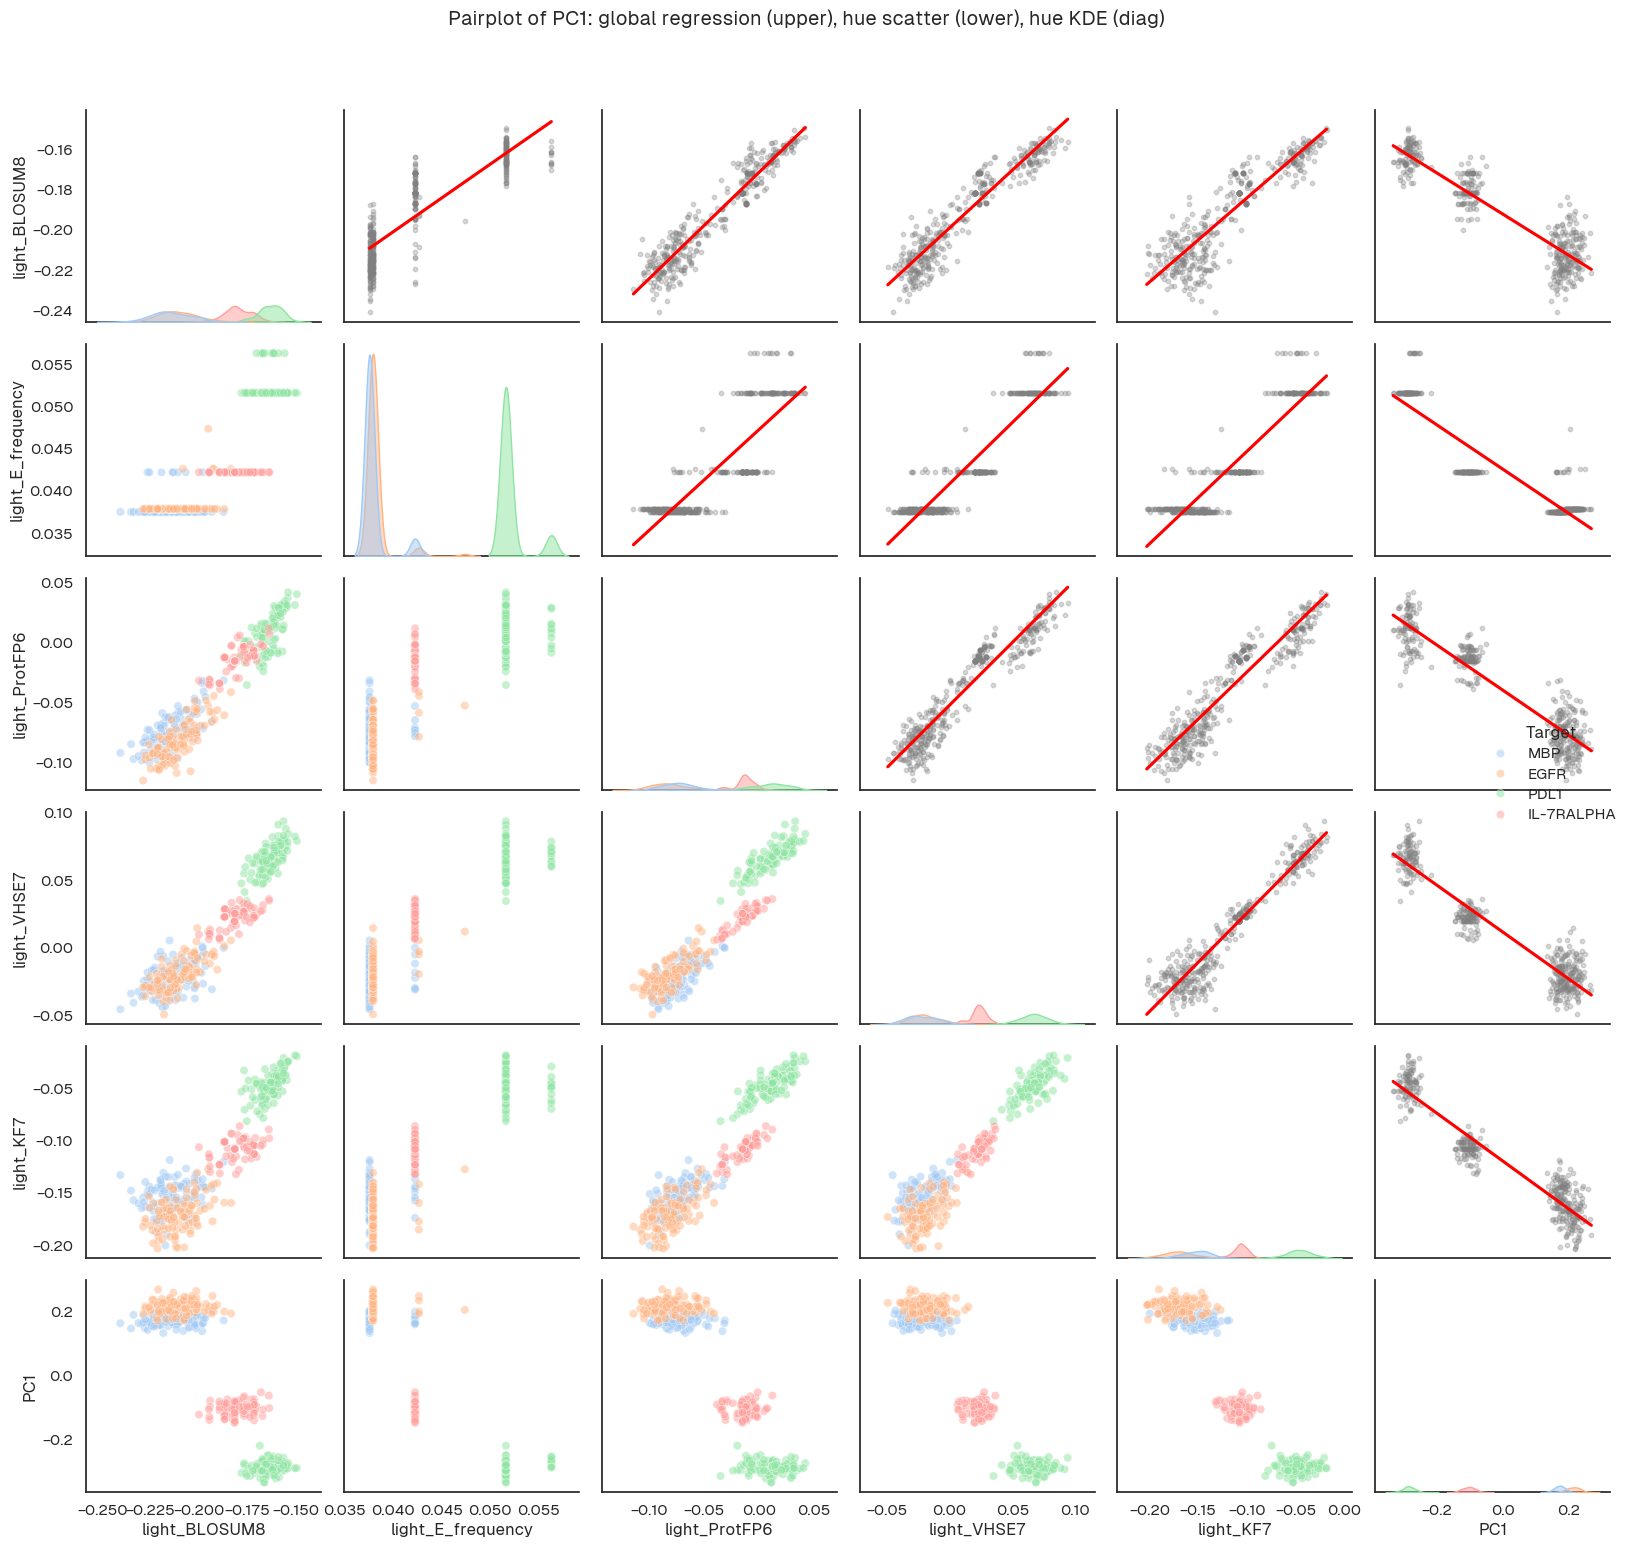

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top_feats = top_correlations_long[
    top_correlations_long['IgT5 Principal Component'] == component
]['Feature'].tolist()

data = correlation_df[top_feats + [component] + ['target']]

vars_to_plot = top_feats + [component]

g_hue = sns.PairGrid(data, vars=vars_to_plot, hue='target', palette='pastel')

g_hue.map_lower(sns.scatterplot, alpha=0.5)
g_hue.map_diag(sns.kdeplot, fill=True, common_norm=False, alpha=0.5)

g_no_hue = sns.PairGrid(data, vars=vars_to_plot)

def regplot_with_scatter(x, y, **kwargs):
    plt.scatter(x, y, color='#7b9acc', alpha=0.3, s=10)
    sns.regplot(x=x, y=y, scatter=False, line_kws={'color': '#b399c8'}, ci=None)

g_no_hue.map_upper(regplot_with_scatter)

plt.close(g_no_hue.fig)

for i in range(len(vars_to_plot)):
    for j in range(i+1, len(vars_to_plot)):
        ax_src = g_no_hue.axes[i, j]
        ax_dst = g_hue.axes[i, j]

        ax_dst.clear()

        x_data = data[vars_to_plot[j]]
        y_data = data[vars_to_plot[i]]

        ax_dst.scatter(x_data, y_data, color='grey', alpha=0.3, s=10)
        sns.regplot(x=x_data, y=y_data, scatter=False, line_kws={'color': 'red'}, ci=None, ax=ax_dst)

g_hue.add_legend(title='Target')
plt.suptitle(f"Pairplot of {component}: global regression (upper), hue scatter (lower), hue KDE (diag)", y=1.03)
plt.tight_layout()
plt.show()

